Purpose: Look at results of updated, corrected polynomial modeling on three-way shared TSGs across physiotypes and pathway genes (CAM genes, photorespiration, N-metabolism, citrate, and clock genes).<br>
Author: Anna Pardo<br>
Date initiated: July 23, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import json

In [2]:
# load results (modeling & post-hoc)
modres = pd.read_csv("../polymod3_modelres_fullmod_TSGs_pathwaygenes.txt",sep="\t",header="infer")
phres = pd.read_csv("../polymod3_posthocres_TSGs_pathwaygenes.txt",sep="\t",header="infer")
modres.head()

,Sum Sq,Df,F value,Pr(>F),Factors,GeneID,FDR_p
0,0.465785,1,1.333161,2.485871e-01,(Intercept),Yucal.11G006100.v2.1,3.590887e-01
1,147.216687,3,140.453660,3.730225e-73,"poly(ZT, 3)",Yucal.11G006100.v2.1,3.503564e-71
2,0.757162,1,2.167136,1.413804e-01,treat,Yucal.11G006100.v2.1,2.276692e-01
3,2.328701,2,3.332583,3.619521e-02,phys,Yucal.11G006100.v2.1,7.202747e-02
4,0.015806,3,0.015080,9.974731e-01,"poly(ZT, 3):treat",Yucal.11G006100.v2.1,9.992700e-01


In [3]:
modres["Factors"].unique()

array(['(Intercept)', 'poly(ZT, 3)', 'treat', 'phys', 'poly(ZT, 3):treat',
       'poly(ZT, 3):phys', 'treat:phys', 'poly(ZT, 3):treat:phys',
       'Residuals'], dtype=object)

In [4]:
phres.head()

,Comparison,Estimate,SE,t.value,p.value,GeneID,FDR_p
0,CAM - C3+CAM,-0.161012,0.070045,-2.298688,5.533985e-02,Yucal.11G006100.v2.1,0.155789
1,facultative CAM - C3+CAM,-0.149852,0.086278,-1.736850,1.887997e-01,Yucal.11G006100.v2.1,0.396686
2,facultative CAM - CAM,0.011160,0.095818,0.116472,9.924354e-01,Yucal.11G006100.v2.1,1.000000
3,CAM - C3+CAM,-0.078946,0.090571,-0.871650,6.545220e-01,Yucal.15G098200.v2.1,0.915452
4,facultative CAM - C3+CAM,-0.632811,0.111560,-5.672380,3.893534e-08,Yucal.15G098200.v2.1,0.000001


In [6]:
# load pathway & general gene name annotations
pathgenes = pd.read_csv("../photresp_N_citrate_genes_Yucca.csv",sep=",",header="infer")
pathgenes = pathgenes[pathgenes["Pathway"].isin(["PhotResp","N-metab","CA-cycle"])]
pathgenes.head()

,Pathway,gene_family,GeneID,subgenome,gene_name_unique
0,PhotResp,PGP,Yucal.01G302600.v2.1,Ya,Ya_PGP_1
1,PhotResp,PGP,Yucal.22G052300.v2.1,Ya,Ya_PGP_2
2,PhotResp,PGP,YufilH1006999m.g,Yf,Yf_PGP_1
3,PhotResp,PGP,YufilH1040717m.g,Yf,Yf_PGP_2
4,PhotResp,PGP,YufilH1084368m.g,Yf,Yf_PGP_3


In [7]:
camgenes = pd.read_csv("../camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")
clockgenes = pd.read_csv("../circadian_light_genes_by_orthology_Yucca.csv",sep=",",header="infer")

In [8]:
# load overall gene names annotation
gannot = pd.read_csv("../gene_annotations/Yg_bothsg_1geneperrow_genefunctions.txt",sep="\t",header="infer")
gannot.head()

,GeneID,syntelogID,Description
0,Yucal.01G000100.v2.1,recip_syn1,cwf21 domain
1,YufilH1000007m.g,recip_syn2,"DnaJ homolog subfamily A member 2, DNA repair,..."
2,Yucal.01G000200.v2.1,recip_syn2,Endonuclease V
3,YufilH1000011m.g,recip_syn3,"nan, Uncharacterized high-glucose-regulated pr..."
4,Yucal.01G000400.v2.1,recip_syn3,YT521-B-like domain


In [9]:
pathgenes.head()

,Pathway,gene_family,GeneID,subgenome,gene_name_unique
0,PhotResp,PGP,Yucal.01G302600.v2.1,Ya,Ya_PGP_1
1,PhotResp,PGP,Yucal.22G052300.v2.1,Ya,Ya_PGP_2
2,PhotResp,PGP,YufilH1006999m.g,Yf,Yf_PGP_1
3,PhotResp,PGP,YufilH1040717m.g,Yf,Yf_PGP_2
4,PhotResp,PGP,YufilH1084368m.g,Yf,Yf_PGP_3


In [31]:
camgenes.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [32]:
camgenes["Pathway"] = "CAM"
clockgenes["Pathway"] = "Clock"
all_pathways = pd.concat([
    pathgenes,
    camgenes.rename(columns={"gene_abbr":"gene_family","gene_abbr_unique":"gene_name_unique"})[["Pathway","gene_family",
                                                                                               "GeneID","subgenome",
                                                                                               "gene_name_unique"]],
    clockgenes.rename(columns={"gene_name":"gene_family"})[["Pathway","gene_family","GeneID","subgenome","gene_name_unique"]]
])
all_pathways.head()

,Pathway,gene_family,GeneID,subgenome,gene_name_unique
0,PhotResp,PGP,Yucal.01G302600.v2.1,Ya,Ya_PGP_1
1,PhotResp,PGP,Yucal.22G052300.v2.1,Ya,Ya_PGP_2
2,PhotResp,PGP,YufilH1006999m.g,Yf,Yf_PGP_1
3,PhotResp,PGP,YufilH1040717m.g,Yf,Yf_PGP_2
4,PhotResp,PGP,YufilH1084368m.g,Yf,Yf_PGP_3


In [47]:
# save all_pathways
all_pathways.to_csv("../gene_annotations/pathwaysofint_gene_annotations.csv",sep=",",header=True,index=False)

In [12]:
gannot.head()

,GeneID,syntelogID,Description
0,Yucal.01G000100.v2.1,recip_syn1,cwf21 domain
1,YufilH1000007m.g,recip_syn2,"DnaJ homolog subfamily A member 2, DNA repair,..."
2,Yucal.01G000200.v2.1,recip_syn2,Endonuclease V
3,YufilH1000011m.g,recip_syn3,"nan, Uncharacterized high-glucose-regulated pr..."
4,Yucal.01G000400.v2.1,recip_syn3,YT521-B-like domain


In [33]:
# add gene info to modres & phres: make a function to do this cleanly
def add_gene_info(resdf):
    pathres = resdf.merge(all_pathways,how="inner")
    nonpath = resdf.merge(gannot,how="left")
    return pathres.merge(nonpath,how="outer")

In [34]:
mres_annot = add_gene_info(modres)
pres_annot = add_gene_info(phres)

In [35]:
# find the significant model results
sigmod = mres_annot[mres_annot["FDR_p"]<0.05]

In [16]:
len(mres_annot["GeneID"].unique()) - len(sigmod["GeneID"].unique())

14

In [17]:
len(sigmod["GeneID"].unique())

4600

## Update summary table of all results with polynomial modeling & post-hoc results

In [19]:
sumtbl = pd.read_csv("../pathway_genes_results_summary.csv",sep=",",header="infer")
sumtbl.head()

,Pathway,GeneID,Gene Family,Parental Origin,Gene Name,TS in Ya,TS in Yf,TS in CAM,TS in C3+CAM,TS in facCAM,...,facultative CAM_D,polyZT*treat*phys,polyZT*phys,polyZT*treat,ASE_C3+CAM_W,ASE_C3+CAM_D,ASE_facultative CAM_W,ASE_CAM_W,ASE_facultative CAM_D,ASE_CAM_D
0,CAM-dark,Yucal.01G165600.v2.1,bCA1234,Ya,Ya_bCA1234_1,Y,N,N,N,N,...,UP,sig,no result,sig,"Ya, 10.0%","Ya, 40.0%; Yf, 10.0%","Ya, 20.0%","Ya, 16.7%",no result,"Ya, 16.7%"
1,CAM-dark,Yucal.02G112700.v2.1,bCA1234,Ya,Ya_bCA1234_2,Y,N,N,N,N,...,ELD_P2,not sig,no result,not sig,"Yf, 100.0%","Yf, 90.0%","Yf, 100.0%","Yf, 83.3%","Yf, 60.0%","Yf, 83.3%"
2,CAM-dark,Yucal.04G001000.v2.1,bCA5,Ya,Ya_bCA5_1,N,N,Y,N,N,...,"DOWN, ELD_P2, ADD",sig,sig,sig,"Ya, 70.0%","Ya, 60.0%; Yf, 20.0%","Ya, 80.0%","Ya, 100.0%","Ya, 40.0%","Ya, 83.3%"
3,CAM-dark,Yucal.07G000800.v2.1,bCA5,Ya,Ya_bCA5_2,Y,N,N,N,N,...,"ELD_P1, ADD",sig,sig,sig,"Ya, 100.0%","Ya, 90.0%","Ya, 100.0%","Ya, 83.3%","Ya, 60.0%","Ya, 83.3%"
4,CAM-dark,Yucal.03G120900.v2.1,NAD-MDH-cp,Ya,Ya_NAD-MDH-cp_1,Y,N,N,N,N,...,DOWN,not sig,no result,not sig,"Ya, 50.0%","Ya, 50.0%","Ya, 60.0%","Ya, 33.3%","Ya, 40.0%","Ya, 33.3%"


In [20]:
# drop prior polymod columns
sumtbl = sumtbl.drop(["polyZT*treat*phys","polyZT*phys","polyZT*treat"],axis=1)
sumtbl.head()

,Pathway,GeneID,Gene Family,Parental Origin,Gene Name,TS in Ya,TS in Yf,TS in CAM,TS in C3+CAM,TS in facCAM,...,C3+CAM_W,CAM_W,facultative CAM_W,facultative CAM_D,ASE_C3+CAM_W,ASE_C3+CAM_D,ASE_facultative CAM_W,ASE_CAM_W,ASE_facultative CAM_D,ASE_CAM_D
0,CAM-dark,Yucal.01G165600.v2.1,bCA1234,Ya,Ya_bCA1234_1,Y,N,N,N,N,...,"ADD, ELD_P1, UP","UP, ELD_P2","ELD_P1, UP",UP,"Ya, 10.0%","Ya, 40.0%; Yf, 10.0%","Ya, 20.0%","Ya, 16.7%",no result,"Ya, 16.7%"
1,CAM-dark,Yucal.02G112700.v2.1,bCA1234,Ya,Ya_bCA1234_2,Y,N,N,N,N,...,"ADD, ELD_P2","ELD_P2, ADD, UP",ELD_P2,ELD_P2,"Yf, 100.0%","Yf, 90.0%","Yf, 100.0%","Yf, 83.3%","Yf, 60.0%","Yf, 83.3%"
2,CAM-dark,Yucal.04G001000.v2.1,bCA5,Ya,Ya_bCA5_1,N,N,Y,N,N,...,"DOWN, ELD_P2, UP","ELD_P1, ELD_P2","ELD_P2, DOWN, ELD_P1","DOWN, ELD_P2, ADD","Ya, 70.0%","Ya, 60.0%; Yf, 20.0%","Ya, 80.0%","Ya, 100.0%","Ya, 40.0%","Ya, 83.3%"
3,CAM-dark,Yucal.07G000800.v2.1,bCA5,Ya,Ya_bCA5_2,Y,N,N,N,N,...,"DOWN, UP",DOWN,DOWN,"ELD_P1, ADD","Ya, 100.0%","Ya, 90.0%","Ya, 100.0%","Ya, 83.3%","Ya, 60.0%","Ya, 83.3%"
4,CAM-dark,Yucal.03G120900.v2.1,NAD-MDH-cp,Ya,Ya_NAD-MDH-cp_1,Y,N,N,N,N,...,"DOWN, ELD_P2","DOWN, ELD_P2",DOWN,DOWN,"Ya, 50.0%","Ya, 50.0%","Ya, 60.0%","Ya, 33.3%","Ya, 40.0%","Ya, 33.3%"


In [21]:
mres_annot["Factors"].unique()

array(['(Intercept)', 'poly(ZT, 3)', 'treat', 'phys', 'poly(ZT, 3):treat',
       'poly(ZT, 3):phys', 'treat:phys', 'poly(ZT, 3):treat:phys',
       'Residuals'], dtype=object)

In [ ]:
phres.head()

In [ ]:
# set up columns for significance of all factors
factdict = {"GeneID":[]}
for i in mres_annot["Factors"].unique():
    if i!="Residuals":
        factdict[i] = []

In [ ]:
# add post-hoc information columns
for i in phres["Comparison"].unique():
    factdict[i] = []

In [ ]:
# populate the dictionary
for i in sumtbl["GeneID"].unique():
    if i in list(modres["GeneID"]):
        factdict["GeneID"].append(i)
        moddf = modres[modres["GeneID"]==i]
        phdf = phres[phres["GeneID"]==i]
        for k,v in factdict.items():
            if k in list(modres["Factors"]):
                #print(k)
                pval = moddf.loc[moddf['Factors'] == k, 'FDR_p'].iloc[0]
                if pval < 0.05:
                    v.append("significant")
                else:
                    v.append("not significant")
            elif k in list(phres["Comparison"]):
                #print(k)
                pval = phdf.loc[phdf["Comparison"]==k,"FDR_p"].iloc[0]
                if pval < 0.05:
                    v.append("significant")
                else:
                    v.append("not significant")

In [ ]:
sumtbl_withstats = sumtbl.merge(pd.DataFrame(factdict),how="left")
sumtbl_withstats.head()

In [ ]:
sumtbl_withstats.to_csv("./pathway_genes_results_updatedpolymod.csv",sep=",",header=True,index=False)

## July 28, 2026: Re-make boxplot figures

In [139]:
# figure plotting function
def plot_pathway(path,resdf,dropfacs=["(Intercept)","Residuals"],save=True,d="./"):
    # remove Residuals and other levels to drop
    resdf = resdf[~resdf["Factors"].isin(dropfacs)]
    
    yares = resdf[resdf["subgenome"]=="Ya"]
    yfres = resdf[resdf["subgenome"]=="Yf"]
    
    yapath = yares[yares["Pathway"]==path]
    yfpath = yfres[yfres["Pathway"]==path]
    
    fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,10),sharex=True,sharey=True)
    ax[0].axvline(x=0.05)
    sns.boxplot(ax=ax[0],data=yapath,y="gene_family",x="FDR_p",hue="Factors")
    sns.stripplot(ax=ax[0],data=yapath,y="gene_family",x="FDR_p",hue="Factors")
    ax[0].set_title("Y. aloifolia origin (CAM)",fontsize=20)
    ax[0].tick_params(which="both",labelsize=16)
    ax[0].set_ylabel("Gene Family",fontsize=16)
    ax[0].set_xlabel("FDR-adjusted p value",fontsize=16)
    ax[0].get_legend().remove()

    ax[1].axvline(x=0.05)
    sns.boxplot(ax=ax[1],data=yfpath,y="gene_family",x="FDR_p",hue="Factors")
    sns.stripplot(ax=ax[1],data=yfpath,y="gene_family",x="FDR_p",hue="Factors")
    ax[1].set_title("Y. filamentosa origin (C3)",fontsize=20)
    ax[1].tick_params(which="both",labelsize=16)
    ax[1].set_ylabel("")
    ax[1].set_xlabel("FDR-adjusted p value",fontsize=16)

    fig.tight_layout()
    plt.legend(bbox_to_anchor=(1,1))

    if save:
        if not os.path.exists(d):
            os.makedirs(d)

        fname = path+"_polymod_byphysTA_pvals"
        plt.savefig(os.path.join(d,fname+".png"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fname+".pdf"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fname+".svg"),dpi=300,bbox_inches="tight")

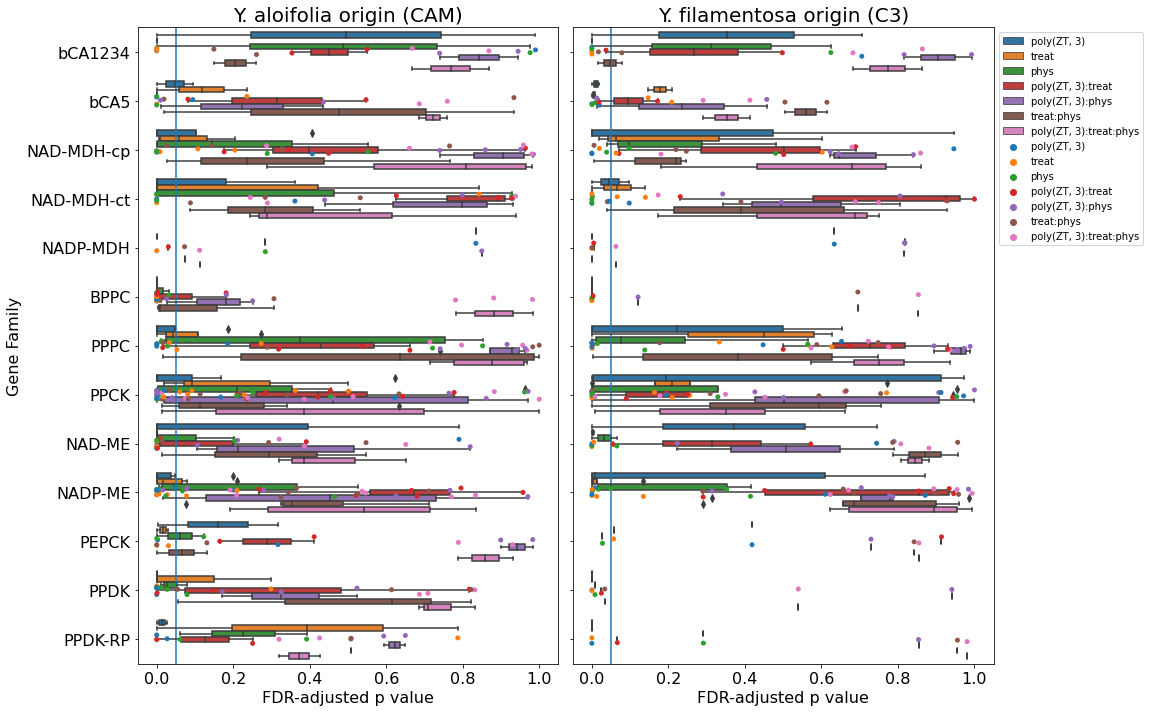

In [140]:
plot_pathway("CAM",mres_annot,save=False)

In [49]:
mres_annot["Pathway"].unique()

array(['Clock', 'CAM', 'PhotResp', 'N-metab', 'CA-cycle', nan],
      dtype=object)

In [54]:
mres_annot["Pathway"] = mres_annot["Pathway"].fillna("Other")

In [74]:
# fix the subgenome column so even genes with pathway=Other have subgenome info
sg = []
for i in mres_annot["GeneID"]:
    if i.startswith("Yucal"):
        sg.append("Ya")
    else:
        sg.append("Yf")
mres_annot["subgenome"] = sg

In [75]:
yares = mres_annot[mres_annot["subgenome"]=="Ya"]
yfres = mres_annot[mres_annot["subgenome"]=="Yf"]

In [76]:
# drop Intercept and Residuals
yares = yares[~yares["Factors"].isin(["(Intercept)","Residuals"])]
yfres = yfres[~yfres["Factors"].isin(["(Intercept)","Residuals"])]

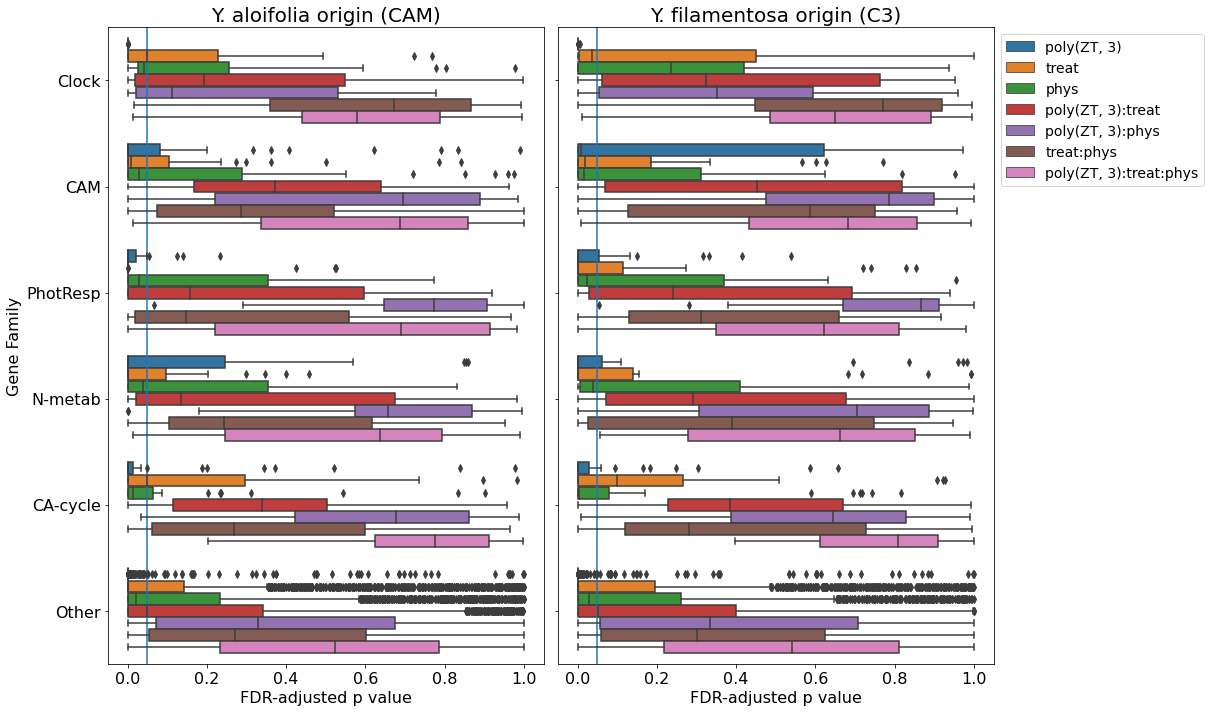

In [83]:
# make a new boxplot: categories = each pathway overall, plus three-way TSGs not included in any of these five pathways
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,10),sharey=True)

ax[0].axvline(x=0.05)
sns.boxplot(ax=ax[0],data=yares,y="Pathway",x="FDR_p",hue="Factors")
#sns.stripplot(ax=ax[0],data=yares,y="Pathway",x="FDR_p",hue="Factors")
ax[0].set_title("Y. aloifolia origin (CAM)",fontsize=20)
ax[0].tick_params(which="both",labelsize=16)
ax[0].set_ylabel("Gene Family",fontsize=16)
ax[0].set_xlabel("FDR-adjusted p value",fontsize=16)
ax[0].get_legend().remove()

ax[1].axvline(x=0.05)
sns.boxplot(ax=ax[1],data=yfres,y="Pathway",x="FDR_p",hue="Factors")
#sns.stripplot(ax=ax[1],data=yfres,y="Pathway",x="FDR_p",hue="Factors")
ax[1].set_title("Y. filamentosa origin (C3)",fontsize=20)
ax[1].tick_params(which="both",labelsize=16)
ax[1].set_ylabel("")
ax[1].set_xlabel("FDR-adjusted p value",fontsize=16)

fig.tight_layout()
plt.legend(bbox_to_anchor=(1,1),fontsize=14)

plt.savefig("./polymod_res_bypathway_boxplot.svg",dpi=300,bbox_inches="tight")

In [82]:
# save files real quick
mres_annot.to_csv("./polymod3_fullmodel_results_withannot.txt",sep="\t",header=True,index=False)
pres_annot.to_csv("./polymod3_fullmodel_posthoc_withannot.txt",sep="\t",header=True,index=False)

In [84]:
pres_annot.head()

,Comparison,Estimate,SE,t.value,p.value,GeneID,FDR_p,Pathway,gene_family,subgenome,gene_name_unique,syntelogID,Description
0,CAM - C3+CAM,-0.161012,0.070045,-2.298688,5.533985e-02,Yucal.11G006100.v2.1,0.155789,Clock,TOC1,Ya,Ya_TOC1_1,recip_syn19224,Two-component response regulator-like PRR1
1,facultative CAM - C3+CAM,-0.149852,0.086278,-1.736850,1.887997e-01,Yucal.11G006100.v2.1,0.396686,Clock,TOC1,Ya,Ya_TOC1_1,recip_syn19224,Two-component response regulator-like PRR1
2,facultative CAM - CAM,0.011160,0.095818,0.116472,9.924354e-01,Yucal.11G006100.v2.1,1.000000,Clock,TOC1,Ya,Ya_TOC1_1,recip_syn19224,Two-component response regulator-like PRR1
3,CAM - C3+CAM,-0.078946,0.090571,-0.871650,6.545220e-01,Yucal.15G098200.v2.1,0.915452,Clock,TOC1,Ya,Ya_TOC1_2,recip_syn24124,Two-component response regulator-like PRR1
4,facultative CAM - C3+CAM,-0.632811,0.111560,-5.672380,3.893534e-08,Yucal.15G098200.v2.1,0.000001,Clock,TOC1,Ya,Ya_TOC1_2,recip_syn24124,Two-component response regulator-like PRR1


In [85]:
# July 30, 2026
# plot post-hoc physiotype results, somehow
## first: find genes that are significant for 'phys'
sigphys = list(mres_annot[(mres_annot["FDR_p"]<0.05)&(mres_annot["Factors"]=="phys")]["GeneID"].unique())
sigphys[0]

'Yucal.15G098200.v2.1'

In [86]:
# subset post-hoc results by this gene list
posthoc_sigphys = pres_annot[pres_annot["GeneID"].isin(sigphys)]
posthoc_sigphys.head()

,Comparison,Estimate,SE,t.value,p.value,GeneID,FDR_p,Pathway,gene_family,subgenome,gene_name_unique,syntelogID,Description
3,CAM - C3+CAM,-0.078946,0.090571,-0.871650,6.545220e-01,Yucal.15G098200.v2.1,0.915452,Clock,TOC1,Ya,Ya_TOC1_2,recip_syn24124,Two-component response regulator-like PRR1
4,facultative CAM - C3+CAM,-0.632811,0.111560,-5.672380,3.893534e-08,Yucal.15G098200.v2.1,0.000001,Clock,TOC1,Ya,Ya_TOC1_2,recip_syn24124,Two-component response regulator-like PRR1
5,facultative CAM - CAM,-0.553865,0.123895,-4.470433,2.504510e-05,Yucal.15G098200.v2.1,0.000303,Clock,TOC1,Ya,Ya_TOC1_2,recip_syn24124,Two-component response regulator-like PRR1
6,CAM - C3+CAM,-0.281232,0.100925,-2.786535,1.483909e-02,Yucal.16G106200.v2.1,0.055770,Clock,TOC1,Ya,Ya_TOC1_3,recip_syn25040,Two-component response regulator-like PRR1
7,facultative CAM - C3+CAM,-0.430889,0.124314,-3.466124,1.653066e-03,Yucal.16G106200.v2.1,0.009566,Clock,TOC1,Ya,Ya_TOC1_3,recip_syn25040,Two-component response regulator-like PRR1


In [87]:
len(sigphys)

2605

In [90]:
posthoc_sigphys["Pathway"] = posthoc_sigphys["Pathway"].fillna("Other")
posthoc_sigphys["Pathway"].unique()

/tmp/ipykernel_140/605570935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posthoc_sigphys["Pathway"] = posthoc_sigphys["Pathway"].fillna("Other")


array(['Clock', 'CAM', 'PhotResp', 'N-metab', 'CA-cycle', 'Other'],
      dtype=object)

In [102]:
posthoc_sigphys["Comparison"].unique()

array(['CAM - C3+CAM', 'facultative CAM - C3+CAM',
       'facultative CAM - CAM'], dtype=object)

In [103]:
# adjust the values of the Comparison column
compdict = {
    "CAM - C3+CAM":"CAM > C3+CAM",
    "facultative CAM - C3+CAM":"facultative CAM > C3+CAM",
    "facultative CAM - CAM":"facultative CAM > CAM"
}
posthoc_sigphys["Comparison"] = posthoc_sigphys["Comparison"].map(compdict)

/tmp/ipykernel_140/626797353.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posthoc_sigphys["Comparison"] = posthoc_sigphys["Comparison"].map(compdict)


In [104]:
# make a boxplot by gene family for the CAM pathway only
camsigs = posthoc_sigphys[posthoc_sigphys["Pathway"]=="CAM"]

In [105]:
len(camsigs["GeneID"].unique())

42

In [135]:
# split plotting by subgenome
## set up a function to do so
def plotfam_posthoc_bysg(path,save=True,d="./"):
    sigs = posthoc_sigphys[posthoc_sigphys["Pathway"]==path]
    
    fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,10),sharey=True)

    sgs = ["Ya","Yf"]
    for i in range(0,2):
        pdf = sigs[sigs["subgenome"]==sgs[i]]
        ax[i].axvline(0.05)
        sns.boxplot(ax=ax[i],data=pdf,y="gene_family",x="FDR_p",hue="Comparison")
        sns.stripplot(ax=ax[i],data=pdf,y="gene_family",x="FDR_p",hue="Comparison")
        ax[i].tick_params(which="both",labelsize=16)
        ax[i].set_xlabel("FDR-adjusted p-value",fontsize=16)
        ax[i].set_ylabel("")
        
        if i==0:
            ax[i].get_legend().remove()
            ax[i].set_title("Y. aloifolia genes",fontsize=20)
        else:
            ax[i].set_title("Y. filamentosa genes",fontsize=20)
    
    if path not in ["PhotResp","N-metab"]:
        plt.suptitle(path+" Polynomial Modeling Post-Hoc Results",fontsize=24)
    elif path=="PhotResp":
        plt.suptitle("Photorespiration Polynomial Modeling Post-Hoc Results",fontsize=24)
    elif path=="N-metab":
        plt.suptitle("Nitrogen Metabolism Polynomial Modeling Post-Hoc Results",fontsize=24)
        
    fig.tight_layout()
    
    plt.legend(bbox_to_anchor=(1,1))
    
    if save:
        if not os.path.exists(d):
            os.makedirs(d)
            
        figbase = path+"_physposthoc_boxplot"
        plt.savefig(os.path.join(d,figbase+".png"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,figbase+".svg"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,figbase+".pdf"),dpi=300,bbox_inches="tight")
    
    plt.show()

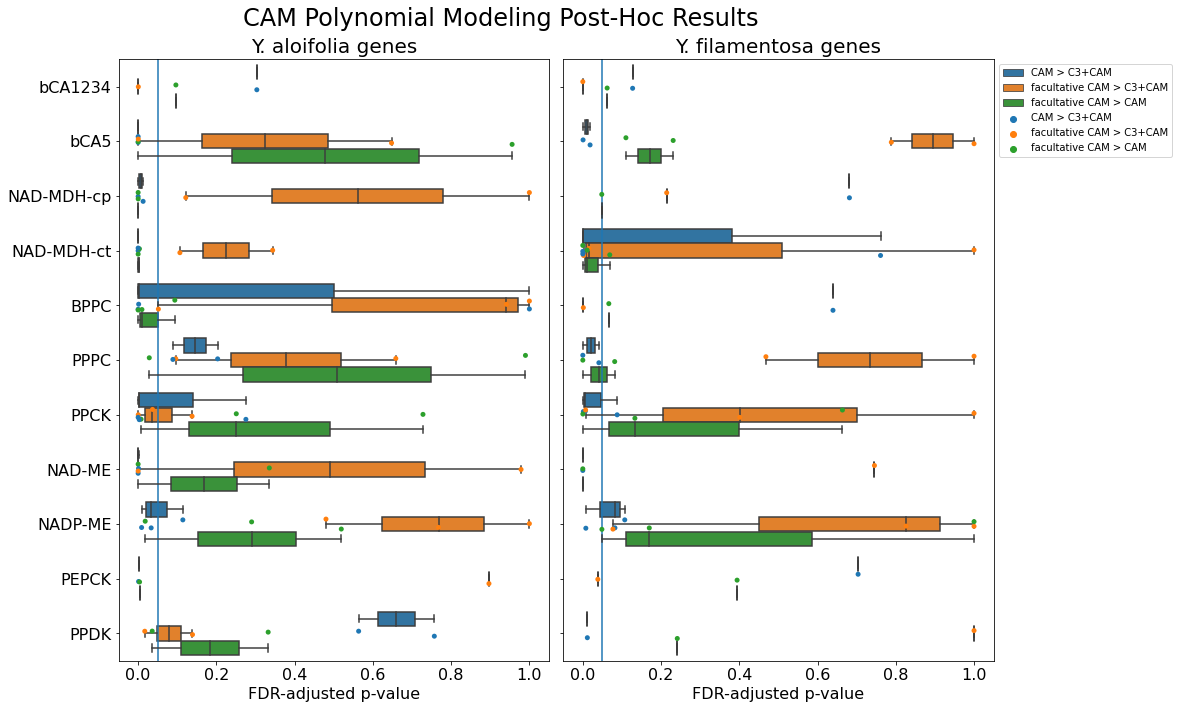

In [131]:
plotfam_posthoc_bysg("CAM",d="./pval_boxplots/")

In [143]:
set(mres_annot[mres_annot["Pathway"]=="CAM"]["gene_family"]).difference(set(camsigs["gene_family"]))

{'NADP-MDH', 'PPDK-RP'}

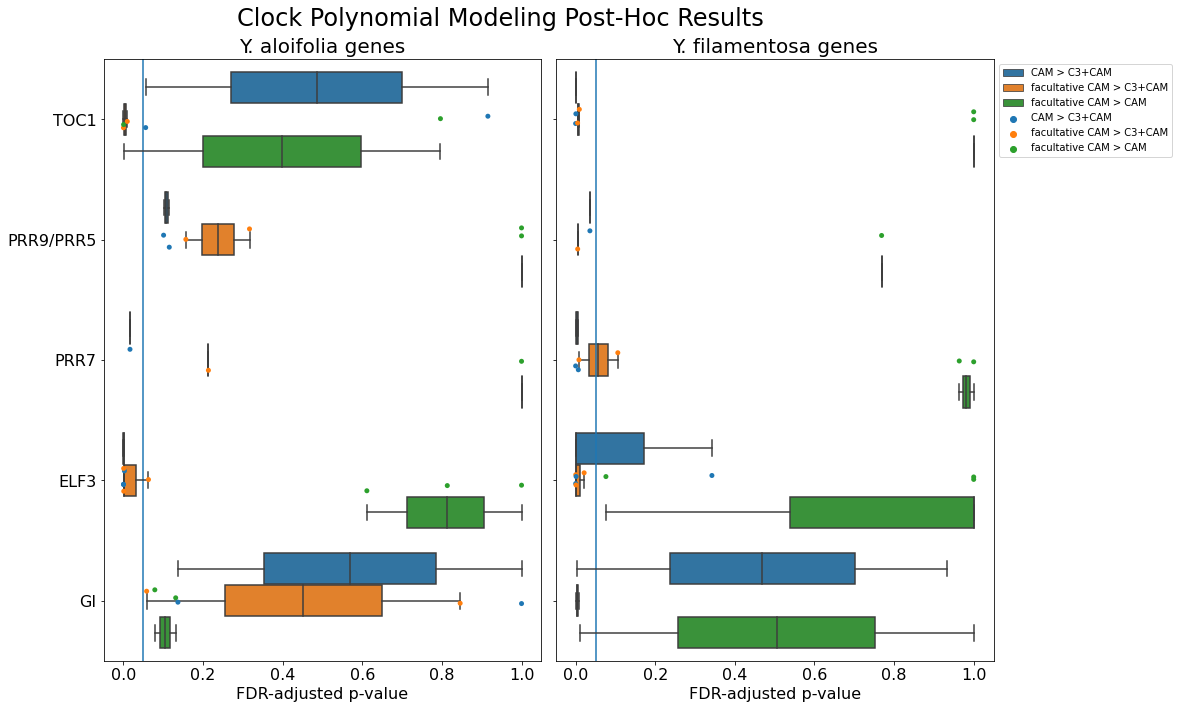

In [132]:
plotfam_posthoc_bysg("Clock")

In [133]:
posthoc_sigphys["Pathway"].unique()

array(['Clock', 'CAM', 'PhotResp', 'N-metab', 'CA-cycle', 'Other'],
      dtype=object)

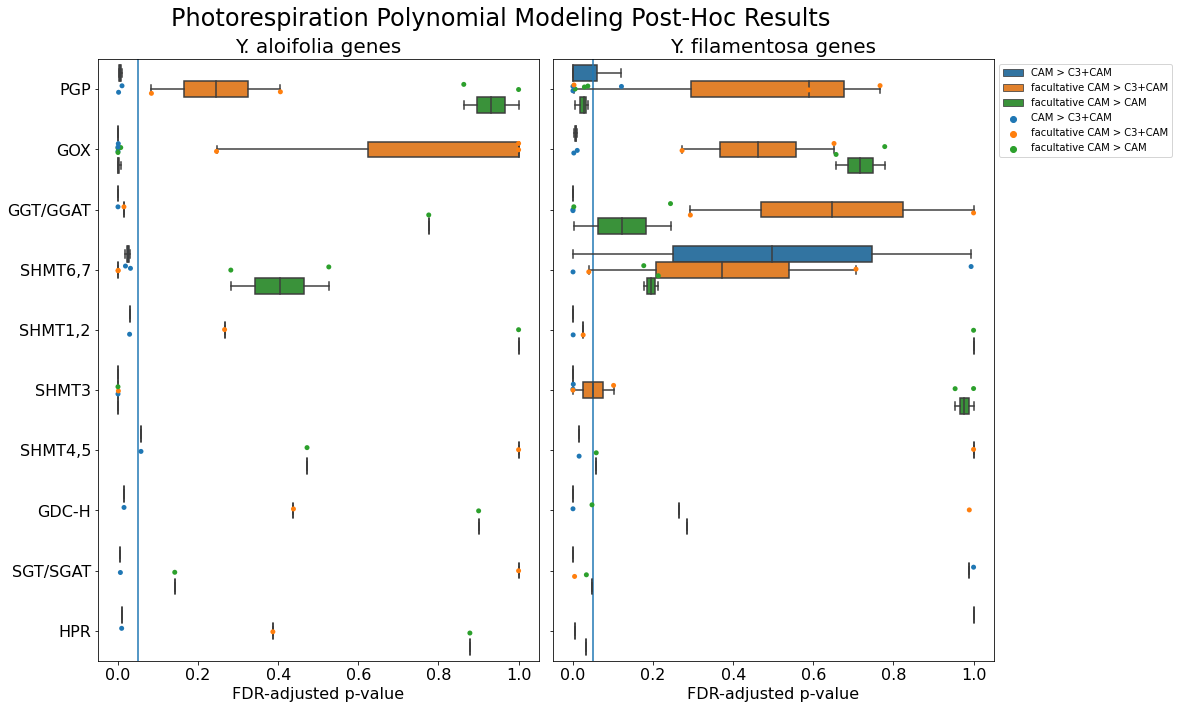

In [136]:
plotfam_posthoc_bysg("PhotResp")

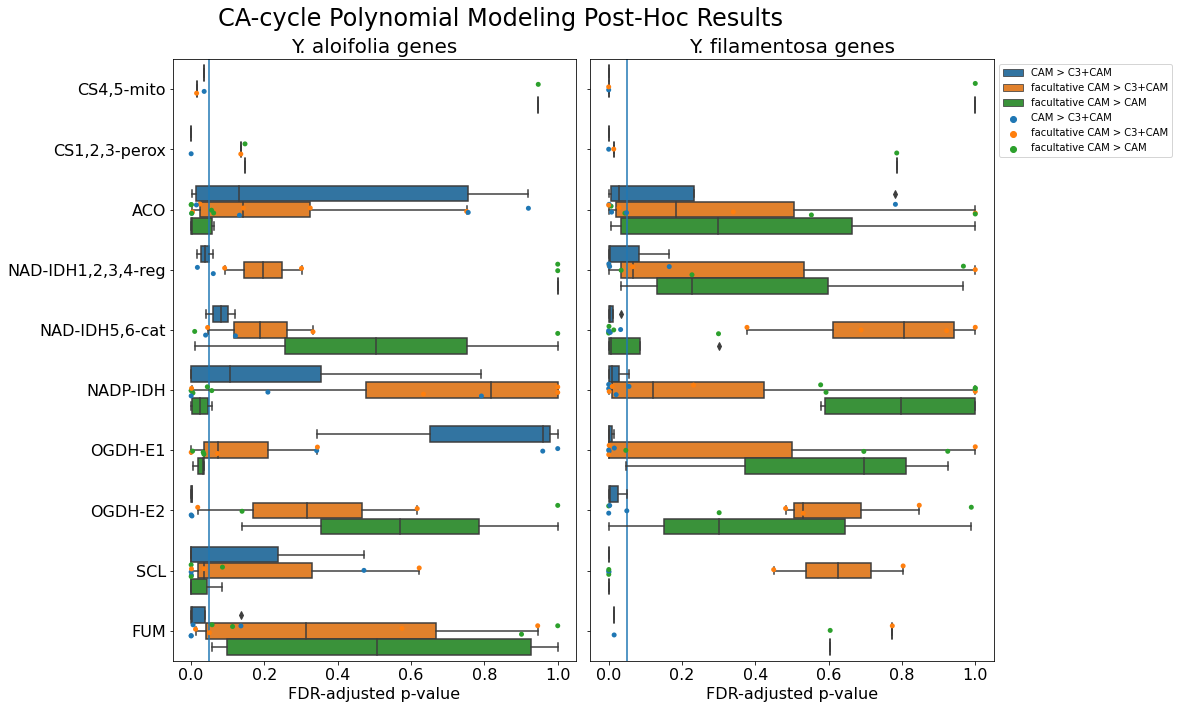

In [137]:
plotfam_posthoc_bysg("CA-cycle")

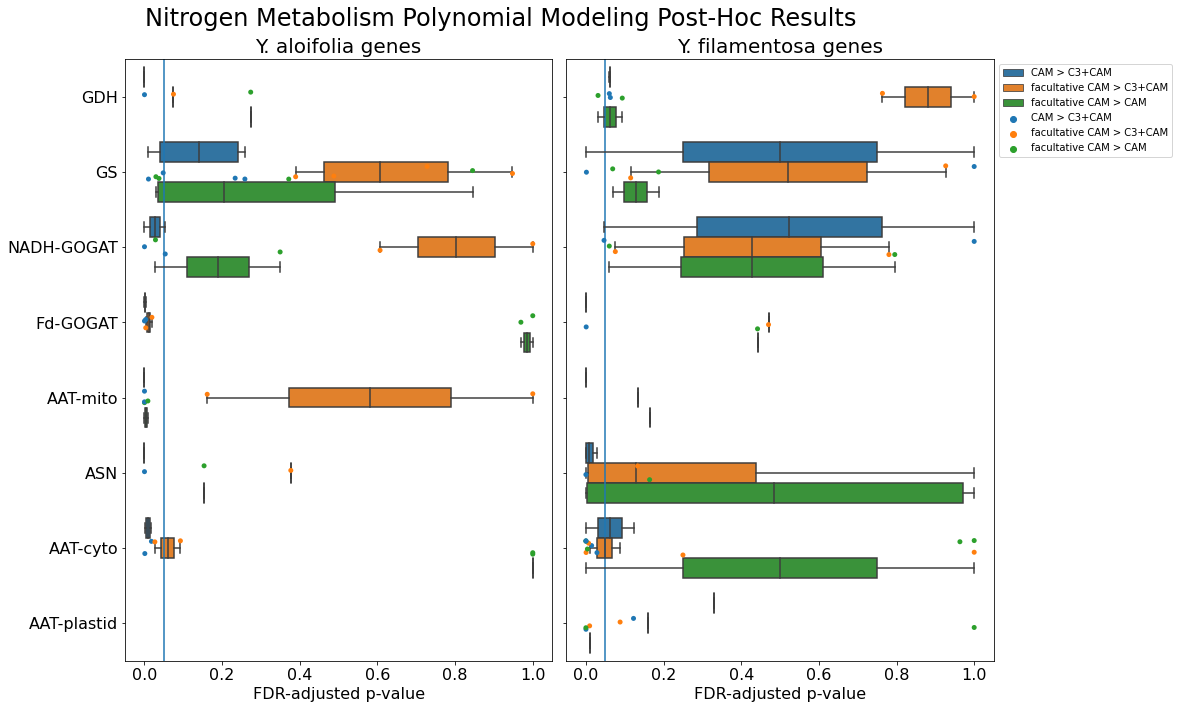

In [138]:
plotfam_posthoc_bysg("N-metab")

In [147]:
sumtbl = pd.read_csv("../pathway_genes_results_updatedpolymod.csv",sep=",",header="infer")

In [151]:
# look into genes with highest expression in C3+CAM (i.e. significant for physiotype, but not significant for any post-hoc
## comparisons (as C3+CAM was the base level for all))

c3camtbl = sumtbl[["Pathway","Gene Family","Gene Name","phys","CAM - C3+CAM","facultative CAM - C3+CAM",
                  "facultative CAM - CAM"]]

In [152]:
c3camtbl = c3camtbl[(c3camtbl["CAM - C3+CAM"]=="not significant")&(c3camtbl["facultative CAM - C3+CAM"]=="not significant")&
                   (c3camtbl["facultative CAM - CAM"]=="not significant")&(c3camtbl["phys"]=="significant")]

In [155]:
phystbl = sumtbl[["Pathway","Gene Family","Gene Name","phys","CAM - C3+CAM","facultative CAM - C3+CAM",
                  "facultative CAM - CAM"]]
phystbl = phystbl[phystbl["phys"]=="significant"]

In [156]:
# find genes with highest expression in CAM Y. gloriosa
camtbl = phystbl[(phystbl["CAM - C3+CAM"]=="significant")&(phystbl["facultative CAM - CAM"]=="not significant")]
camtbl.head()

,Pathway,Gene Family,Gene Name,phys,CAM - C3+CAM,facultative CAM - C3+CAM,facultative CAM - CAM
3,CAM-dark,bCA5,Ya_bCA5_2,significant,significant,significant,not significant
21,CAM-dark,PPCK,Ya_PPCK_3,significant,significant,significant,not significant
22,CAM-dark,PPCK,Ya_PPCK_4,significant,significant,significant,not significant
27,CAM-light,NAD-ME,Ya_NAD-ME_2,significant,significant,significant,not significant
32,CAM-light,NADP-ME,Ya_NADP-ME_4,significant,significant,not significant,not significant


In [168]:
# find genes with highest expression in facultative CAM Y. gloriosa
factbl = phystbl[(phystbl["facultative CAM - C3+CAM"]=="significant")|
                (phystbl["facultative CAM - CAM"]=="significant")]
factbl.head()

,Pathway,Gene Family,Gene Name,phys,CAM - C3+CAM,facultative CAM - C3+CAM,facultative CAM - CAM
0,CAM-dark,bCA1234,Ya_bCA1234_1,significant,not significant,significant,not significant
2,CAM-dark,bCA5,Ya_bCA5_1,significant,significant,not significant,significant
3,CAM-dark,bCA5,Ya_bCA5_2,significant,significant,significant,not significant
5,CAM-dark,NAD-MDH-cp,Ya_NAD-MDH-cp_2,significant,significant,not significant,significant
7,CAM-dark,NAD-MDH-cp,Ya_NAD-MDH-cp_4,significant,significant,not significant,significant
